In [1]:
import time
import warnings

import catboost
import lightgbm
import xgboost
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from joblib import delayed, Parallel
from sklearn import linear_model, svm, tree, ensemble, neighbors
from sklearn.metrics import (f1_score, roc_auc_score, classification_report, 
                             roc_curve, precision_recall_curve, auc)
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from src.outlier_generator import OutlierGenerator
from src.read_dataset import load, Dataset

warnings.filterwarnings('ignore') # Wyciszenie ostrzeżeń (np. od sklearn czy xgboost) dla czystości wyników
sns.set_theme(style="whitegrid", palette="muted")

In [2]:
# KOMÓRKA 2: Definicje algorytmów
tested_outlier_fns = [
    "uniform",
    "normal",
    "extreme"
]

# Modele binarne, które zostaną przekazane do wrappera
tested_binary_algorithms = [
    linear_model.LogisticRegression,
    svm.LinearSVC,
    tree.DecisionTreeClassifier,
    ensemble.RandomForestClassifier,
    xgboost.XGBClassifier,
    # catboost.CatBoostClassifier,
    lightgbm.LGBMClassifier
]

# Standardowe algorytmy do klasyfikacji jednoklasowej (baselines)
tested_oneclass_algorithms = [
    ensemble.IsolationForest,
    linear_model.SGDOneClassSVM,
    neighbors.LocalOutlierFactor
]

# Zbiory danych do przetestowania (zgodnie z dokumentacją)
# Odkomentuj kolejne, jeśli je pobrałeś
datasets_to_test = [
    Dataset.ODDS, 
    Dataset.HAR, 
    Dataset.DFVE
]

In [3]:
# KOMÓRKA 3: Funkcje do ewaluacji wizualnej
def evaluate_and_plot_curves(model, X_test, y_test, model_name, is_baseline=False):
    """Generuje raport klasyfikacji oraz rysuje krzywe ROC i PR."""
    preds = model.predict(X_test)
    
    # MAPOWANIE PREDYKCJI: ujednolicenie na standard zbioru testowego (0 = Inlier, 1 = Outlier)
    if is_baseline:
        # Algorytmy jednoklasowe sklearn: 1 (inlier), -1 (outlier)
        preds_mapped = np.where(preds == 1, 0, 1)
        # Pobieranie ciągłych wyników: wyższy wynik -> anomalia
        scores = -model.decision_function(X_test) if hasattr(model, "decision_function") else preds_mapped
    else:
        # OutlierGenerator: 1 (inlier), 0 (outlier)
        preds_mapped = np.where(preds == 1, 0, 1)
        try:
            # Prawdopodobieństwo klasy "0" z perspektywy modelu binarnego (czyli wygenerowanego outlier'a)
            scores = model.predict_proba(X_test)[:, 0]
        except AttributeError:
            if hasattr(model._estimator, "decision_function"):
                scores = -model._estimator.decision_function(X_test)
            else:
                scores = preds_mapped
                
    print(f"\n{'-'*55}")
    print(f"Raport Klasyfikacji: {model_name}")
    print(f"{'-'*55}")
    print(classification_report(y_test, preds_mapped, target_names=["Inlier (0)", "Outlier (1)"]))
    
    fpr, tpr, _ = roc_curve(y_test, scores, pos_label=1)
    roc_auc = auc(fpr, tpr)
    
    precision, recall, _ = precision_recall_curve(y_test, scores, pos_label=1)
    pr_auc = auc(recall, precision)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc:.3f}')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax1.set(xlim=[0.0, 1.0], ylim=[0.0, 1.05], xlabel='FPR', ylabel='TPR', title=f'ROC - {model_name}')
    ax1.legend(loc="lower right")
    
    ax2.plot(recall, precision, color='green', lw=2, label=f'PR AUC = {pr_auc:.3f}')
    ax2.set(xlim=[0.0, 1.0], ylim=[0.0, 1.05], xlabel='Recall', ylabel='Precision', title=f'PR - {model_name}')
    ax2.legend(loc="lower left")
    
    plt.tight_layout()
    plt.show()

def plot_pca_decision_boundary(model_class, model_kwargs, is_baseline, X_train, y_train, X_test, y_test, title):
    """Rzutuje dane na 2 wymiary za pomocą PCA i wizualizuje obszary decyzyjne."""
    pca = PCA(n_components=2, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    # Trening TYLKO na inlierach
    X_train_normal_pca = X_train_pca[y_train == 0]
    
    model = model_class(**model_kwargs)
    model.fit(X_train_normal_pca)
    
    pad_x = (X_test_pca[:, 0].max() - X_test_pca[:, 0].min()) * 0.1
    pad_y = (X_test_pca[:, 1].max() - X_test_pca[:, 1].min()) * 0.1
    x_min, x_max = X_test_pca[:, 0].min() - pad_x, X_test_pca[:, 0].max() + pad_x
    y_min, y_max = X_test_pca[:, 1].min() - pad_y, X_test_pca[:, 1].max() + pad_y
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    Z = model.predict(grid_points)
    
    # Mapowanie siatki na standard 0/1
    if is_baseline:
        Z_mapped = np.where(Z == 1, 0, 1)
    else:
        Z_mapped = np.where(Z == 1, 0, 1)
        
    Z_mapped = Z_mapped.reshape(xx.shape)
    
    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z_mapped, alpha=0.3, cmap='coolwarm')
    scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', edgecolor='k', alpha=0.8)
    
    handles, _ = scatter.legend_elements()
    plt.legend(handles, ["Inlier (Klasa 0)", "Outlier (Klasa 1)"], loc="upper right")
    plt.title(f"PCA Obszary Decyzyjne (2D) - {title}", fontsize=14)
    plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} wariancji)")
    plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} wariancji)")
    plt.tight_layout()
    plt.show()

def run_binary_experiment(clf_class, out_fn, X_train, X_test, y_test, dataset_name):
    model_name = clf_class.__name__
    experiment_name = f"{model_name} ({out_fn})"
    
    # Ustawienie argumentów (w tym wielowątkowości)
    kwargs = {'random_state': 42}
    
    if model_name in ['RandomForestClassifier']:
        kwargs['n_jobs'] = -1
    elif model_name == 'CatBoostClassifier':
        kwargs['verbose'] = False
        kwargs['thread_count'] = -1
        kwargs['allow_writing_files'] = False  # <-- Dodaj tę linijkę
    elif model_name == 'LGBMClassifier':
        kwargs['verbose'] = -1
        kwargs['n_jobs'] = -1
    elif model_name == 'XGBClassifier':
        kwargs['eval_metric'] = 'logloss'
        kwargs['n_jobs'] = -1
    elif model_name == 'LinearSVC':
        kwargs['dual'] = False # Przyspiesza działanie, gdy próbek jest więcej niż cech
    
    base_estimator = clf_class(**kwargs)
    model = OutlierGenerator(estimator=base_estimator, outliers_fn=out_fn, random_state=42)
    
    start_time = time.time()
    model.fit(X_train) 
    preds = model.predict(X_test)
    # print(preds)
    fit_time = time.time() - start_time
    
    # Mapowanie i ewaluacja
    preds_mapped = np.where(preds == 1, 0, 1)
    # print(preds_mapped)
    f1 = f1_score(y_test, preds_mapped, pos_label=1)
    roc = roc_auc_score(y_test, preds_mapped)
    
    return {
        "Dataset": dataset_name,
        "Model_Type": "Binary + Generator",
        "Algorithm": model_name,
        "Method": out_fn,
        "Full_Name": experiment_name,
        "F1_Score": f1,
        "ROC_AUC": roc,
        "Time_s": fit_time
    }

def run_baseline_experiment(clf_class, X_train, X_test, y_test, dataset_name):
    model_name = clf_class.__name__
    
    kwargs = {}
    if model_name == 'LocalOutlierFactor':
        kwargs['novelty'] = True
        kwargs['n_jobs'] = -1
    elif model_name == 'IsolationForest':
        kwargs['random_state'] = 42
        kwargs['n_jobs'] = -1
    elif model_name == 'SGDOneClassSVM':
        kwargs['random_state'] = 42
        
    model = clf_class(**kwargs)
        
    start_time = time.time()
    model.fit(X_train) 
    preds = model.predict(X_test)
    fit_time = time.time() - start_time
    
    preds_mapped = np.where(preds == 1, 0, 1)
    f1 = f1_score(y_test, preds_mapped, pos_label=1)
    roc = roc_auc_score(y_test, preds_mapped)
    
    return {
        "Dataset": dataset_name,
        "Model_Type": "One-Class Baseline",
        "Algorithm": model_name,
        "Method": "baseline",
        "Full_Name": model_name,
        "F1_Score": f1,
        "ROC_AUC": roc,
        "Time_s": fit_time
    }

In [4]:
# KOMÓRKA 4: Pętla ucząca modele i zbierająca wyniki do tabeli
results = []

for dataset_name in datasets_to_test:
    print(f"\n{'='*50}\nPrzetwarzanie zbioru: {dataset_name}\n{'='*50}")
    
    # 1. Wczytanie i podział danych
    df, metadata = load(dataset_name)
    
    cols_to_drop = ["label", "label_ratio", "activity"]
    X = df.drop(columns=[col for col in cols_to_drop if col in df.columns]).values
    y = df["label"].values
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Uczymy wyłącznie na przykładach "normalnych" (Inliers = 0)
    X_train_normal = X_train[y_train == 0]
    
    # 2. Testowanie klasyfikatorów binarnych za pomocą zrównoleglenia Joblib
    print("Trenowanie modeli Binary+Generator (obliczenia zrównoleglone)...")
    tasks_binary = [
        delayed(run_binary_experiment)(clf_class, out_fn, X_train_normal, X_test, y_test, dataset_name)
        for clf_class in tested_binary_algorithms
        for out_fn in tested_outlier_fns
    ]
    # Uruchomienie równoległe (n_jobs=-1 wykorzysta wszystkie zasoby)
    binary_results = Parallel(n_jobs=-1, verbose=10)(tasks_binary)
    results.extend(binary_results)
    
    # 3. Testowanie modeli Baseline za pomocą zrównoleglenia Joblib
    print("\nTrenowanie modeli Baseline (obliczenia zrównoleglone)...")
    tasks_baseline = [
        delayed(run_baseline_experiment)(clf_class, X_train_normal, X_test, y_test, dataset_name)
        for clf_class in tested_oneclass_algorithms
    ]
    baseline_results = Parallel(n_jobs=-1, verbose=10)(tasks_baseline)
    results.extend(baseline_results)

print("\nGotowe! Eksperymenty zakończone pomyślnie.")


Przetwarzanie zbioru: ODDS
[ODDS] loaded 567498 samples, 4 columns
Trenowanie modeli Binary+Generator (obliczenia zrównoleglone)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  3 out of 18 | elapsed:    3.6s remaining:   18.6s
[Parallel(n_jobs=-1)]: Done  5 out of 18 | elapsed:    3.8s remaining:    9.9s
[Parallel(n_jobs=-1)]: Done  7 out of 18 | elapsed:    4.2s remaining:    6.7s
[Parallel(n_jobs=-1)]: Done  9 out of 18 | elapsed:    4.6s remaining:    4.6s
[Parallel(n_jobs=-1)]: Done 11 out of 18 | elapsed:    7.6s remaining:    4.8s
[Parallel(n_jobs=-1)]: Done 13 out of 18 | elapsed:    7.7s remaining:    2.9s
[Parallel(n_jobs=-1)]: Done 15 out of 18 | elapsed:    8.3s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done 18 out of 18 | elapsed:    8.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.



Trenowanie modeli Baseline (obliczenia zrównoleglone)...


[Parallel(n_jobs=-1)]: Done 3 out of 3 | elapsed:   14.4s finished



Przetwarzanie zbioru: HAR
[HAR] loaded 10299 samples, 563 columns
Trenowanie modeli Binary+Generator (obliczenia zrównoleglone)...


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.09380578994750977s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  3 out of 18 | elapsed:    0.0s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done  5 out of 18 | elapsed:    0.0s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  7 out of 18 | elapsed:    0.1s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  9 out of 18 | elapsed:    0.1s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 11 out of 18 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 13 out of 18 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 15 out of 18 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 18 out of 18 | elapsed:    0.3s finished



Trenowanie modeli Baseline (obliczenia zrównoleglone)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.09376001358032227s.) Setting batch_size=2.



Gotowe! Eksperymenty zakończone pomyślnie.


[Parallel(n_jobs=-1)]: Done 3 out of 3 | elapsed:    0.2s finished


,Dataset,Model_Type,Algorithm,Method,Full_Name,F1_Score,ROC_AUC,Time_s
12,ODDS,Binary + Generator,XGBClassifier,uniform,XGBClassifier (uniform),0.951561,0.999801,6.680622
62,DFVE,One-Class Baseline,LocalOutlierFactor,baseline,LocalOutlierFactor,0.903326,0.570739,0.217739
41,HAR,One-Class Baseline,LocalOutlierFactor,baseline,LocalOutlierFactor,0.845994,0.866547,0.160745
39,HAR,One-Class Baseline,IsolationForest,baseline,IsolationForest,0.738245,0.755908,0.095952
40,HAR,One-Class Baseline,SGDOneClassSVM,baseline,SGDOneClassSVM,0.727824,0.778256,0.364558
...,...,...,...,...,...,...,...,...
51,DFVE,Binary + Generator,RandomForestClassifier,uniform,RandomForestClassifier (uniform),0.000000,0.500000,0.224566
58,DFVE,Binary + Generator,LGBMClassifier,normal,LGBMClassifier (normal),0.000000,0.500000,0.225332
57,DFVE,Binary + Generator,LGBMClassifier,uniform,LGBMClassifier (uniform),0.000000,0.500000,0.234138
55,DFVE,Binary + Generator,XGBClassifier,normal,XGBClassifier (normal),0.000000,0.500000,0.159893



--- Wykres zbiorczy F1-Score ---


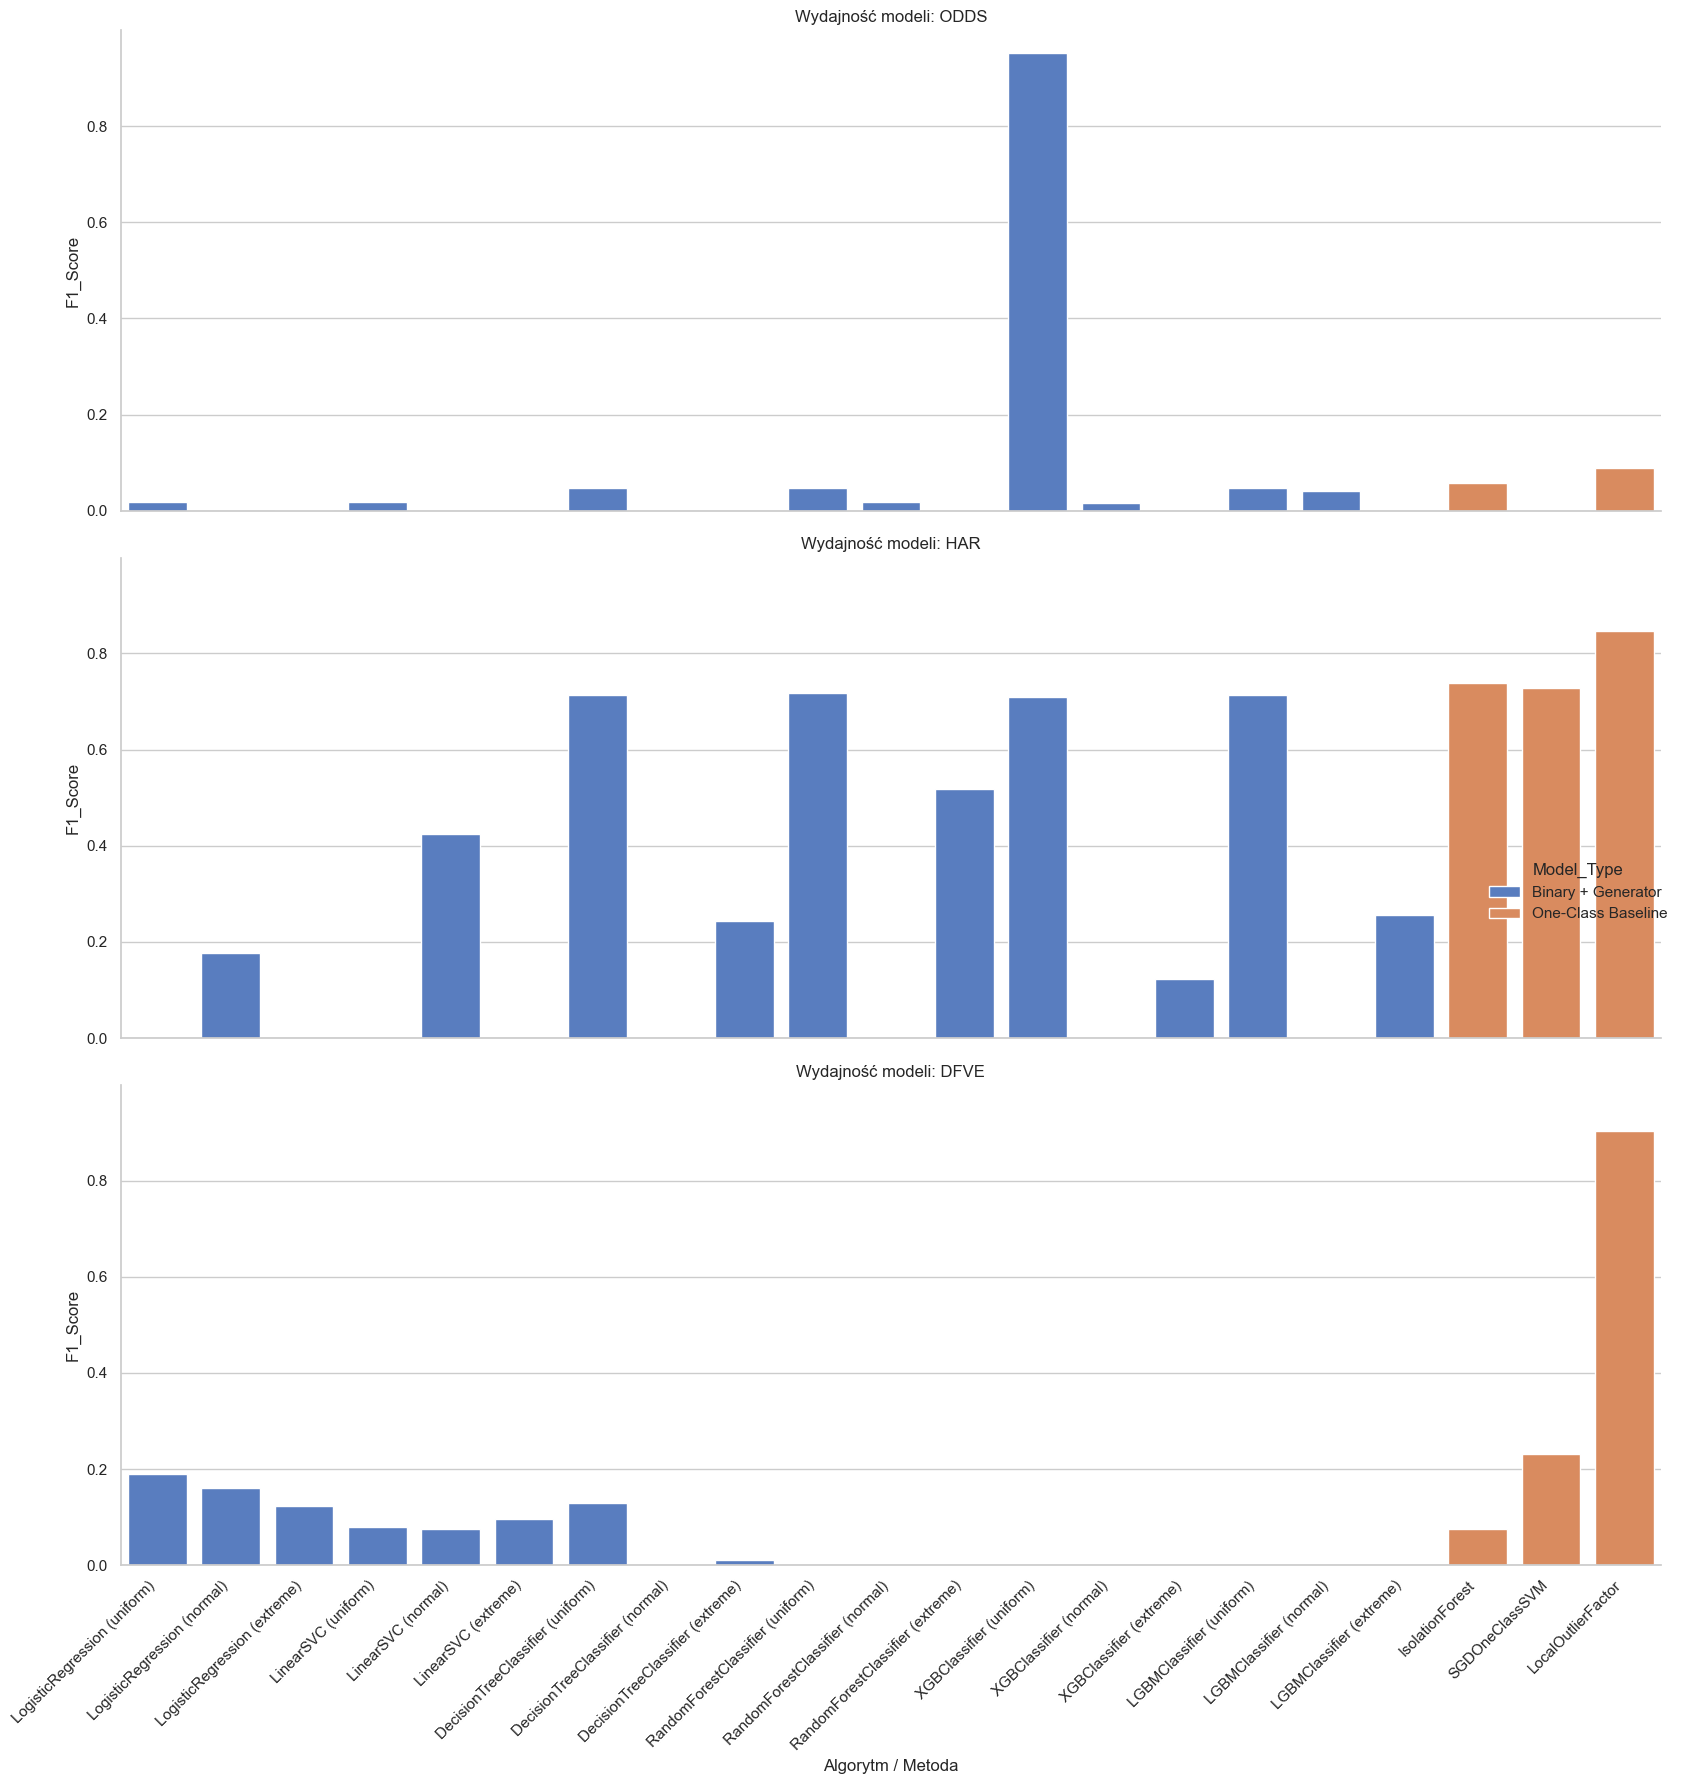


--- Wykres zbiorczy ROC AUC ---


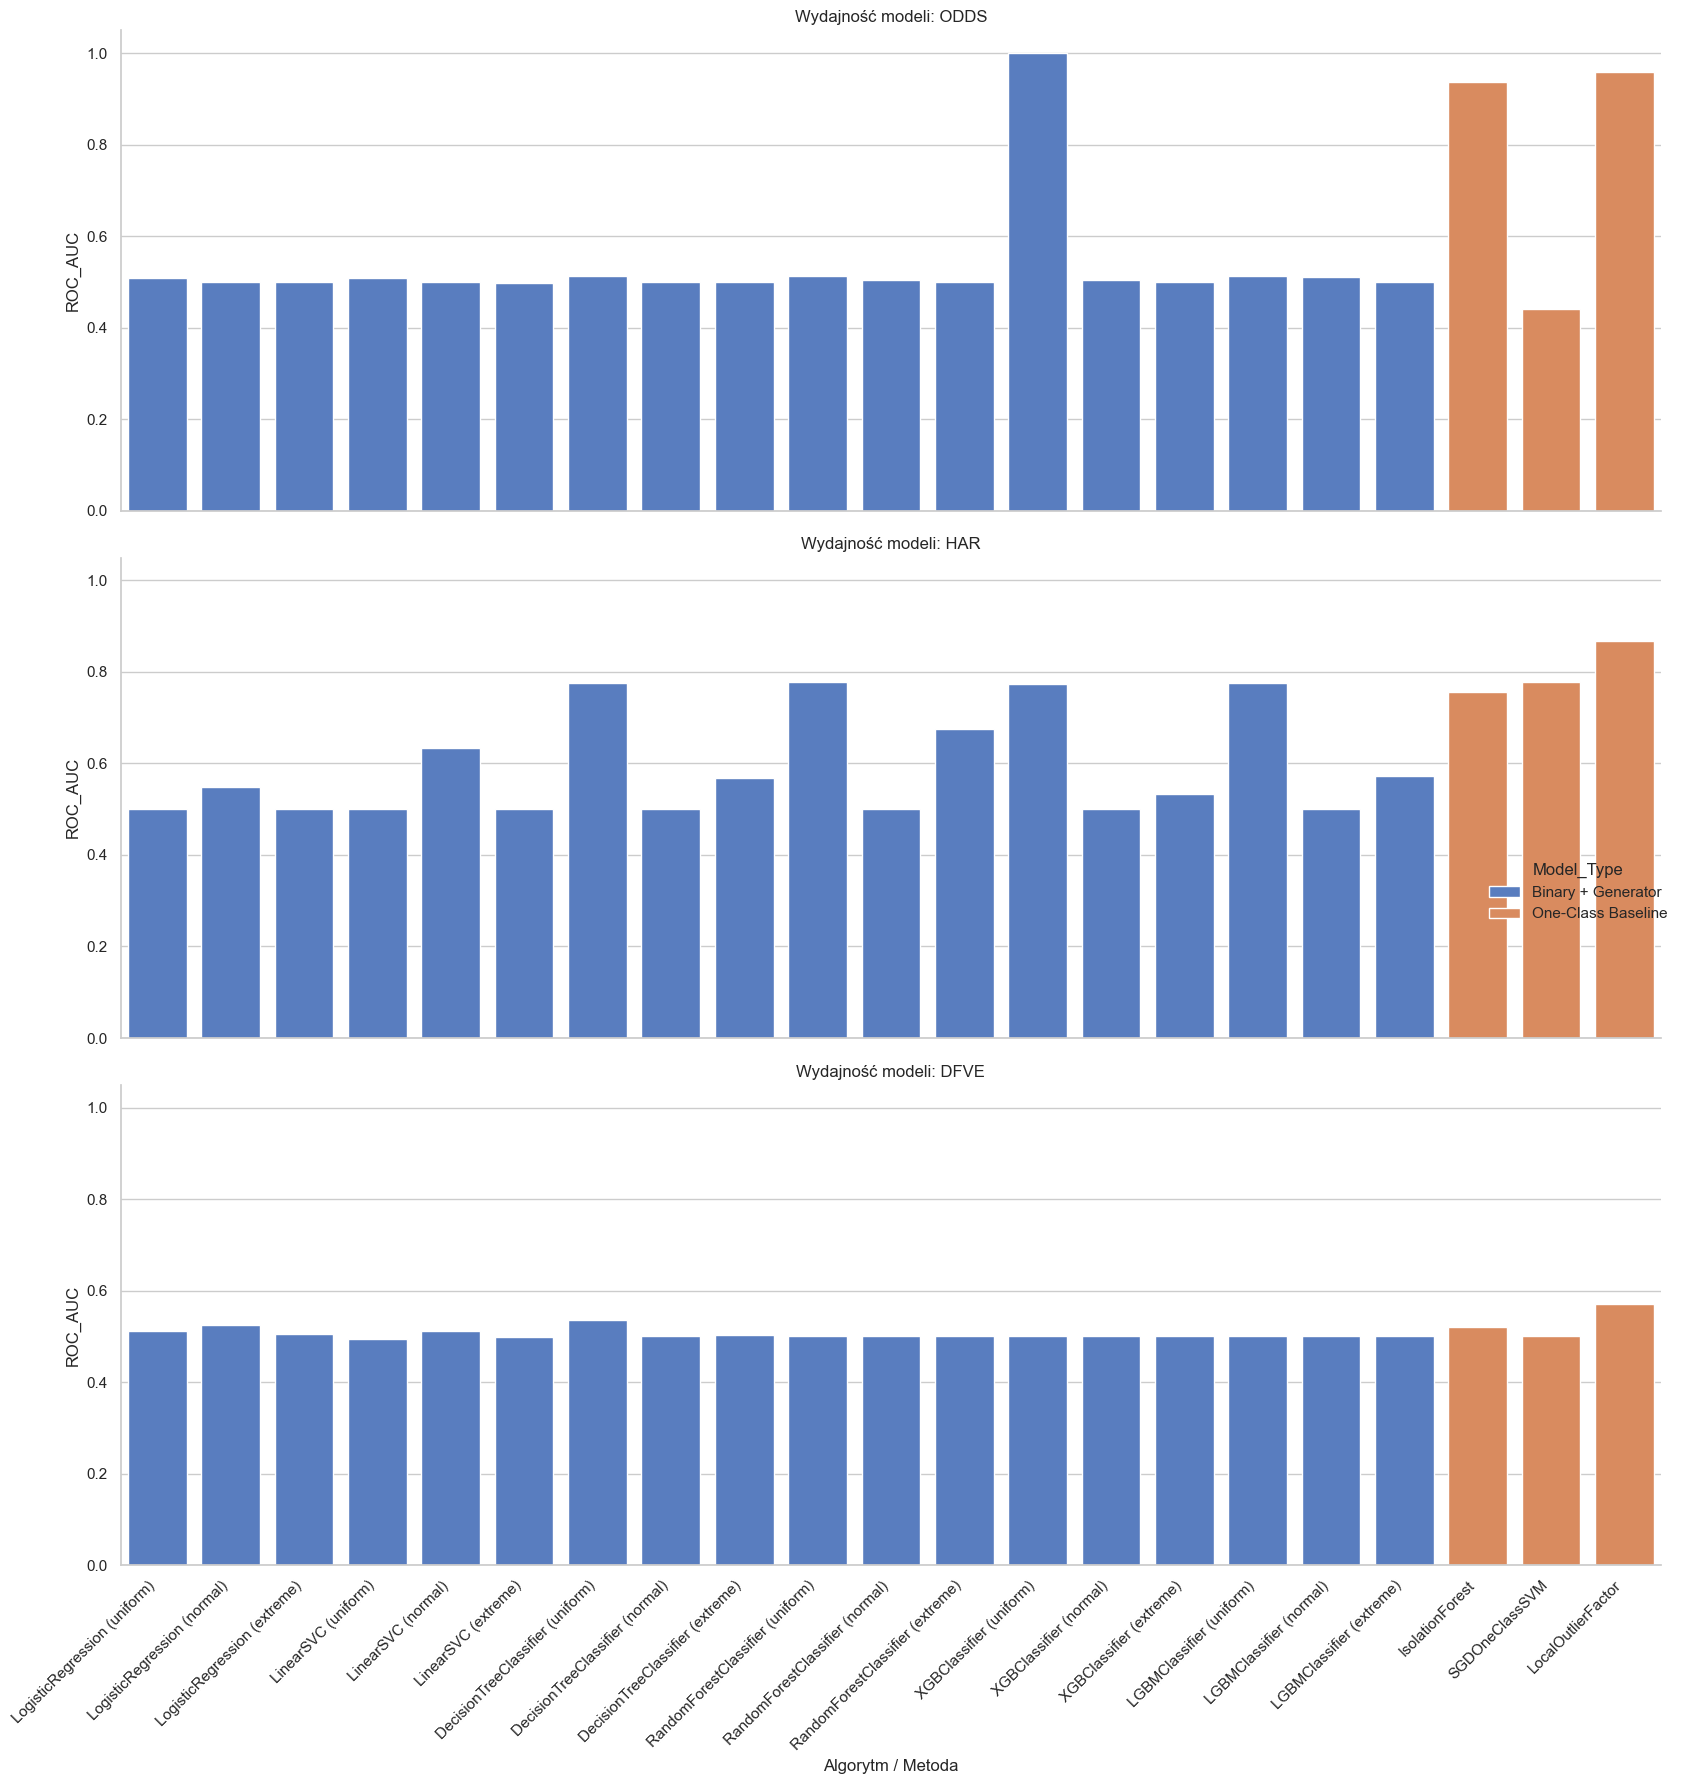

In [7]:
# KOMÓRKA 5: Analiza i wizualizacja w zbiorczej tabeli
df_results = pd.DataFrame(results)
display(df_results.sort_values(by="F1_Score", ascending=False))

def plot_results(df, metric="F1_Score"):
    g = sns.catplot(
        data=df, 
        kind="bar",
        x="Full_Name", 
        y=metric, 
        col="Dataset",
        hue="Model_Type", 
        col_wrap=1,      
        height=6, 
        aspect=2.5,      
        dodge=False
    )
    
    g.set_axis_labels("Algorytm / Metoda", metric)
    g.set_titles("Wydajność modeli: {col_name}")
    
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_horizontalalignment('right')
            
    plt.tight_layout()
    plt.show()

print("\n--- Wykres zbiorczy F1-Score ---")
plot_results(df_results, metric="F1_Score")
print("\n--- Wykres zbiorczy ROC AUC ---")
plot_results(df_results, metric="ROC_AUC")


Generowanie analiz pogłębionych (PCA i Krzywe) dla zbioru ODDS...
[ODDS] loaded 567498 samples, 4 columns

-------------------------------------------------------
Raport Klasyfikacji: Random Forest + Normal Outlier Generator
-------------------------------------------------------
              precision    recall  f1-score   support

  Inlier (0)       1.00      1.00      1.00    113058
 Outlier (1)       0.67      0.01      0.02       442

    accuracy                           1.00    113500
   macro avg       0.83      0.50      0.51    113500
weighted avg       0.99      1.00      0.99    113500



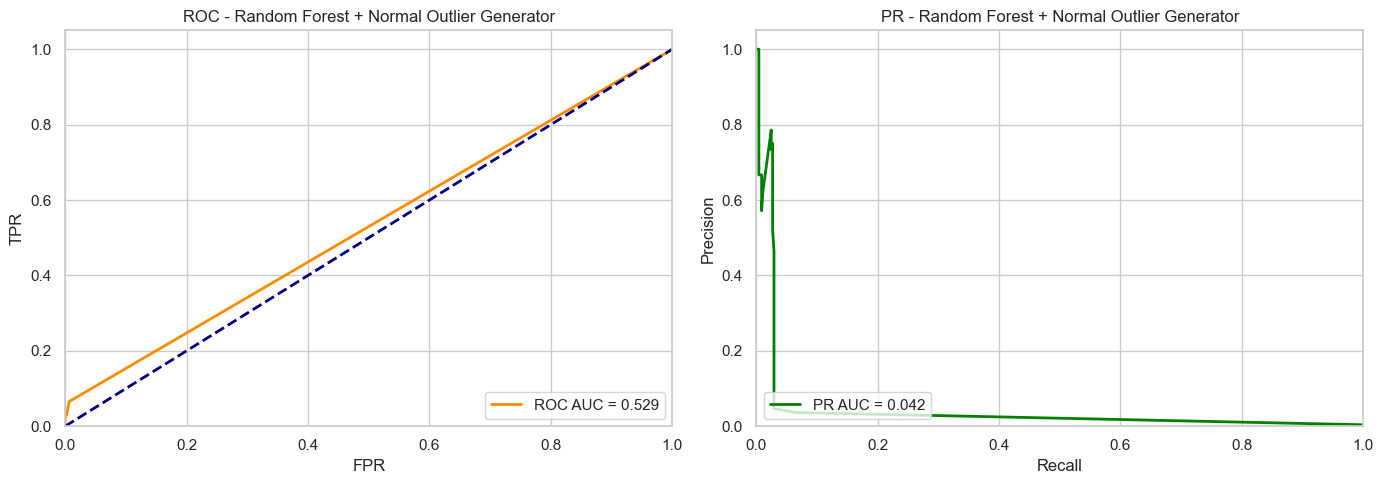

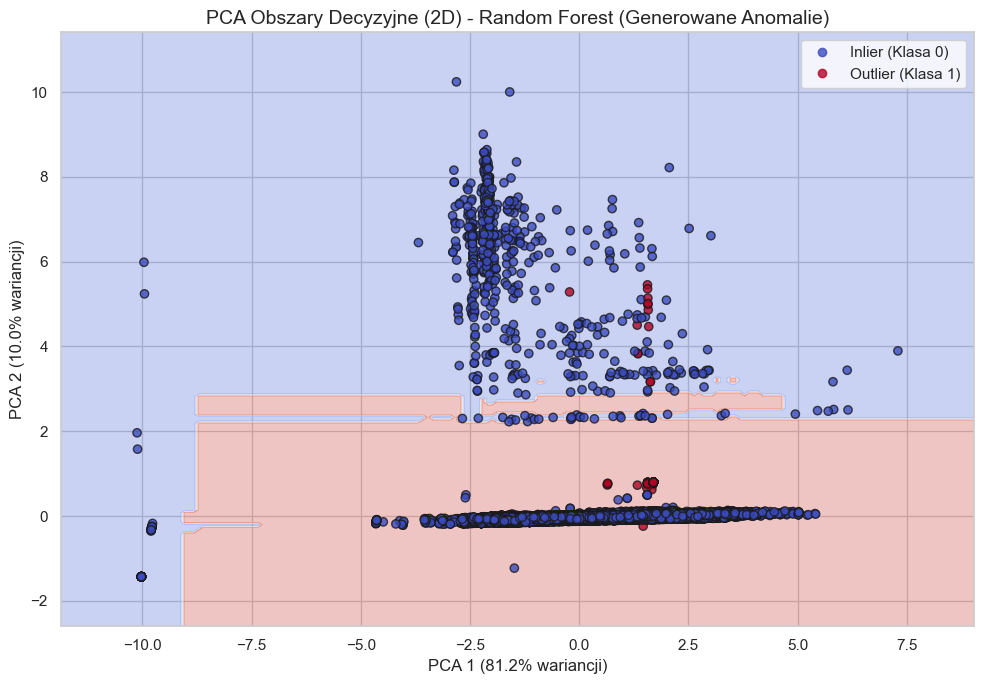


-------------------------------------------------------
Raport Klasyfikacji: Isolation Forest (Baseline)
-------------------------------------------------------
              precision    recall  f1-score   support

  Inlier (0)       1.00      0.87      0.93    113058
 Outlier (1)       0.03      1.00      0.06       442

    accuracy                           0.87    113500
   macro avg       0.52      0.94      0.50    113500
weighted avg       1.00      0.87      0.93    113500



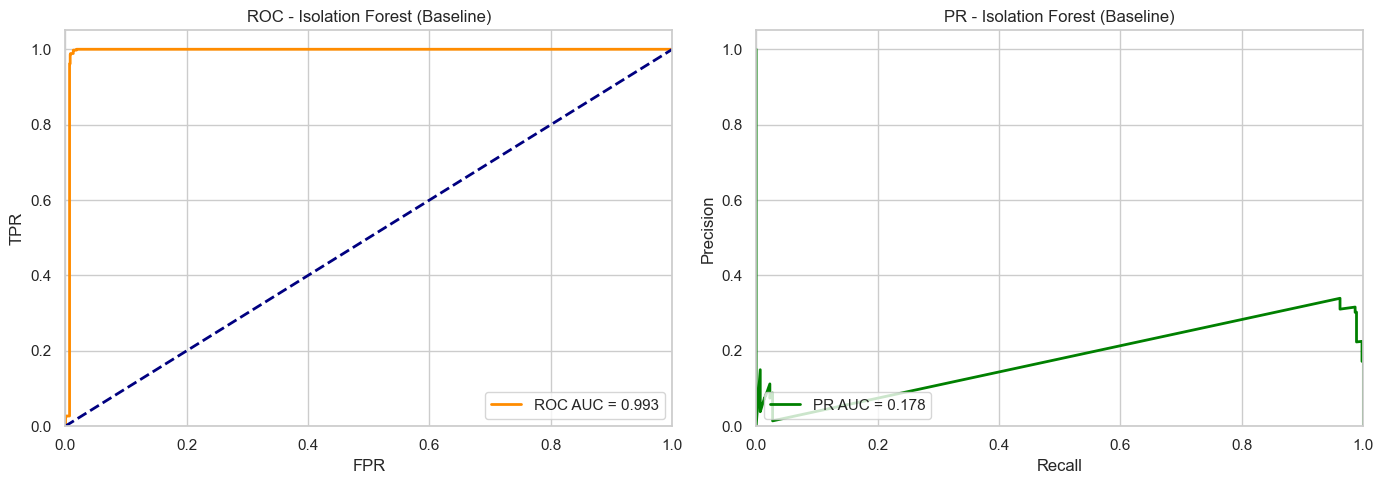

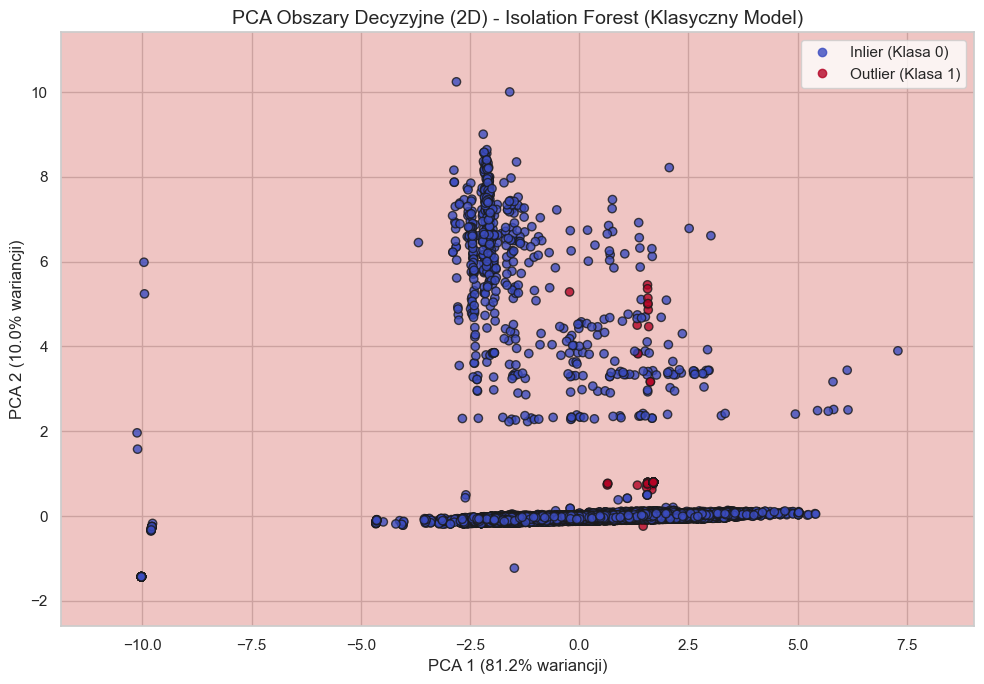

In [8]:
# KOMÓRKA 6: Pogłębiona analiza na wybranym zbiorze danych
print("\nGenerowanie analiz pogłębionych (PCA i Krzywe) dla zbioru ODDS...")

# Pobieramy raz jeszcze do izolacji dla celów wizualizacyjnych
df_eval, _ = load(Dataset.ODDS)
X_eval = df_eval.drop(columns=["label"]).values
y_eval = df_eval["label"].values

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_eval, y_eval, test_size=0.2, random_state=42, stratify=y_eval
)

# Do trenowania PCA bierzemy tylko INLIERS
X_train_normal_e = X_train_e[y_train_e == 0]

# --- 1. Analiza: Przykładowy model Generatora (np. Random Forest + Normal) ---
rf_base = ensemble.RandomForestClassifier(random_state=42)
model_rf_gen = OutlierGenerator(estimator=rf_base, outliers_fn="normal", random_state=42)
model_rf_gen.fit(X_train_normal_e)

evaluate_and_plot_curves(
    model=model_rf_gen, 
    X_test=X_test_e, 
    y_test=y_test_e, 
    model_name="Random Forest + Normal Outlier Generator", 
    is_baseline=False
)

plot_pca_decision_boundary(
    model_class=OutlierGenerator,
    model_kwargs={"estimator": ensemble.RandomForestClassifier(random_state=42), "outliers_fn": "normal", "random_state": 42},
    is_baseline=False,
    X_train=X_train_e, y_train=y_train_e, X_test=X_test_e, y_test=y_test_e,
    title="Random Forest (Generowane Anomalie)"
)

# --- 2. Analiza: Baseline (Isolation Forest) ---
model_iso = ensemble.IsolationForest(random_state=42)
model_iso.fit(X_train_normal_e)

evaluate_and_plot_curves(
    model=model_iso, 
    X_test=X_test_e, 
    y_test=y_test_e, 
    model_name="Isolation Forest (Baseline)", 
    is_baseline=True
)

plot_pca_decision_boundary(
    model_class=ensemble.IsolationForest,
    model_kwargs={"random_state": 42},
    is_baseline=True,
    X_train=X_train_e, y_train=y_train_e, X_test=X_test_e, y_test=y_test_e,
    title="Isolation Forest (Klasyczny Model)"
)